# 8 . Opciones multi-activo: basket, spread, worst-of/best-of y compo (quanto-style)

`GbmBasket` (PLAN_IMPROVE_NOTEBOOK.md, Fase 3) es el primer modelo del motor con mas de un
`observable` correlacionado bajo el mismo browniano: varios activos GBM comparten una matriz
de correlacion instantanea constante, simulados de forma conjunta y vectorizada (Cholesky de la
matriz de correlacion aplicado a shocks independientes, mismo patron que ya usaba
`HullWhite2F` para sus dos factores latentes, generalizado de 2 a N activos). Este notebook
cubre los cuatro productos que motivaron la fase: basket call, spread option, worst-of/best-of,
y una variante "compo" (ver la nota sobre quanto mas abajo) -- todos comparando al menos dos
niveles de correlacion, y razonando en cada caso si el precio sube o baja con la correlacion
(la respuesta NO es la misma para los cuatro productos).

> **Nota (`PLAN_IMPROVE_NOTEBOOK.md`, Fase 3) -- decisiones tomadas:**
>
> - **El AST/compilador de payoff (`CompiledPayoff::observable_slots` en Rust,
>   `expression.hpp`/`docs/schema/engine.payoff/v1.schema.json`/`quantdesk.payoff` en
>   C++/Python) YA soportaba multiples observables distintos en el mismo contrato ANTES de esta
>   fase, sin ningun cambio** -- un `grep` explicito de "basket"/"spread"/"worst_of"/"correlation"
>   en esos tres sitios (la leccion de la Fase 2 del mismo plan: verificar antes de disenar) no
>   encontro nada preexistente, a diferencia de `Average`/`RunningMin`/`RunningMax` en la Fase 2.
>   Lo unico que faltaba era la capa de SIMULACION: ningun modelo sabia generar trayectorias
>   correlacionadas para mas de un observable a la vez.
> - **Params para `GbmBasket` (mecanismo elegido, `cpp/engine/include/engine/model.hpp`)**:
>   `"observables"` es un unico string delimitado por comas (`"EQ.SPOT.A,EQ.SPOT.B"`), NO una
>   lista -- `engine::ParamValue` (`std::variant<double, vector<double>, bool, string>`) no gana
>   un variante `vector<string>` solo para esto (radio de impacto demasiado grande: lo usan TODOS
>   los modelos/productos/medidas del motor). El binding Python (`dict_to_params` en
>   `engine_py_ext.cpp`) traduce `list[str]`/`tuple[str]` a ese string automaticamente, asi que
>   del lado Python `GbmBasket(observables=["EQ.SPOT.A", "EQ.SPOT.B"], ...)` se siente nativo.
>   `"correlation"` SI cabe tal cual en `ParamValue` como `vector<double>` aplanada FILA A FILA.
> - **Misma medida `"PayoffPriceQ"`, no una medida nueva**: `PayoffPriceQMeasure::evaluate`
>   (`measure.cpp`) hace `dynamic_cast` a `GbmModel` primero y a `GbmBasketModel` despues -- el
>   AST/compilador ya es agnostico al numero de observables, asi que un caller no deberia tener
>   que elegir el nombre de la medida segun si el contrato se va a precisar contra un unico
>   activo o un basket.
> - **Fuera de alcance de esta fase (documentado, no oculto)**: sin `valuation_time`/Theta, sin
>   sensibilidades pathwise/Gamma/Vanna, sin `Exercise`/Longstaff-Schwartz ni Brownian bridge
>   continuo para barreras sobre un basket, y sobre todo -- la que mas afecta a este notebook --
>   **todos los activos de un `GbmBasket` deben compartir la MISMA tasa libre de riesgo `r`**
>   (`validate_common_discount_rate` en Rust): el modelo no tiene hoy un numerario de descuento
>   por activo, asi que un quanto "de verdad" (con el ajuste de drift `-rho*sigma_S*sigma_FX`
>   entre el activo extranjero y el tipo de cambio) no esta soportado. La seccion 5 de abajo usa
>   en su lugar un **compo option** (liquida en el producto de dos observables ya simulados, sin
>   necesitar ningun ajuste de drift) y lo etiqueta explicitamente como tal.

In [1]:
import sys
from pathlib import Path
import math

sys.path.insert(0, "../../../build/clients/python")
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

import engine
import quantdesk as q

print("modulo engine importado desde:", engine.__file__)

modulo engine importado desde: S:\Projects\engine_quant\clients\python\notebooks\../../../build/clients/python\engine.cp312-win_amd64.pyd


## 1. `GbmBasket`: dos activos correlacionados

Dos activos `EQ.SPOT.A`/`EQ.SPOT.B`, mismo spot/vol/tasa libre de riesgo por simplicidad (para
que las diferencias de precio entre secciones se deban SOLO a la correlacion y a la forma del
payoff, no a asimetrias de parametros) -- `r` es obligatoriamente la misma para los dos activos
(ver la nota de arriba).

In [2]:
OBS_A, OBS_B = "EQ.SPOT.A", "EQ.SPOT.B"
S0, R, Q_DIV, SIGMA, T = 100.0, 0.03, 0.0, 0.25, 1.0
N_PATHS, SEED = 200_000, 7


def basket_model(rho: float):
    return q.GbmBasket(
        observables=[OBS_A, OBS_B],
        s0=[S0, S0],
        r=[R, R],
        q=[Q_DIV, Q_DIV],
        sigma=[SIGMA, SIGMA],
        correlation=[[1.0, rho], [rho, 1.0]],
    )


market = q.Market(pillars=[T], zero_rates=[R])
eng = q.Engine(backend="cpu", n_paths=N_PATHS, n_steps=1, seed=SEED)


def price_basket(contract, product_id, model):
    trade = q.PayoffProduct(id=product_id, contract=contract)
    return eng.price(trade, model, market, ["PayoffPriceQ"]).PayoffPriceQ.scalar


CORRELATIONS = [0.0, 0.4, 0.8]
print("Niveles de correlacion comparados en todo el notebook:", CORRELATIONS)

Niveles de correlacion comparados en todo el notebook: [0.0, 0.4, 0.8]


## 2. Basket call: `max(S_A(T) + S_B(T) - K, 0)`

Una call sobre la SUMA de los dos activos. Mas correlacion entre A y B implica mas varianza de
la suma (`Var(A+B) = var_A + var_B + 2*rho*cov`), y una opcion vale mas cuanta mas varianza tiene
su subyacente (Jensen/convexidad del payoff) -- el precio del basket call debe SUBIR con la
correlacion.

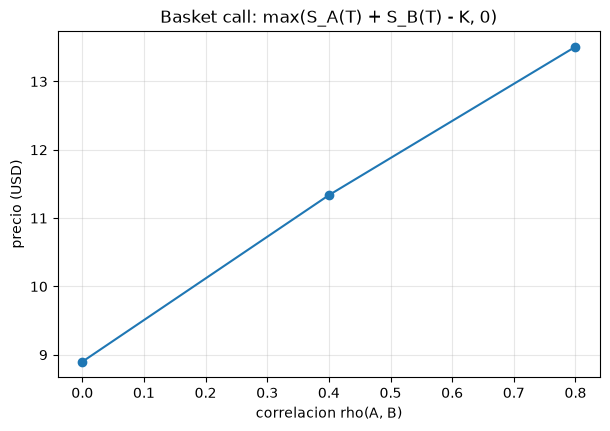

rho=+0.00  basket call = 8.8978
rho=+0.40  basket call = 11.3361
rho=+0.80  basket call = 13.5082

Confirmado: el precio sube con la correlacion (mas varianza de la suma => call mas cara).


In [3]:
K_BASKET = 2 * S0 * 1.10  # ligeramente OTM sobre la suma

basket_contract = q.when(
    T,
    q.cashflow("USD", q.maximum(q.fixing(OBS_A, T) + q.fixing(OBS_B, T) - K_BASKET, 0.0)),
)

basket_prices = [price_basket(basket_contract, f"BASKET_CALL_{rho}", basket_model(rho)) for rho in CORRELATIONS]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(CORRELATIONS, basket_prices, "o-", color="tab:blue")
ax.set_xlabel("correlacion rho(A, B)")
ax.set_ylabel("precio (USD)")
ax.set_title("Basket call: max(S_A(T) + S_B(T) - K, 0)")
ax.grid(alpha=0.3)
plt.show()

for rho, price in zip(CORRELATIONS, basket_prices):
    print(f"rho={rho:+.2f}  basket call = {price:.4f}")

assert basket_prices == sorted(basket_prices), "el basket call deberia subir monotonamente con la correlacion"
print("\nConfirmado: el precio sube con la correlacion (mas varianza de la suma => call mas cara).")

## 2b. Trayectorias, delta por activo y cross-gamma del basket call (`PLAN_IMPROVE_NOTEBOOK2.md` Fase 4)

Hasta aqui `GbmBasket` solo tenia cableada `PayoffPriceQ` (precio) -- `Engine.simulate_paths`
(diagnostico de trayectorias, `PLAN_IMPROVE_NOTEBOOK.md` Fase 0) y `Greek`/`greeks.delta(...)`
(sensibilidades, `PLAN_GREEKS.md`) solo reconocian `GBM`/`GBM_P` de un unico activo. Esta fase
cierra ese hueco:

- **`Engine.simulate_paths` sobre `GbmBasket`**: mismo diagnostico de trayectorias que ya existia
  para GBM/GBM_P, generalizado a N activos correlacionados -- `paths` gana una dimension extra,
  `(n_paths, n_steps+1, n_assets)`.
- **Delta por activo** (`delta_A = dV/dS_A`, `delta_B = dV/dS_B`): decision de diseño tomada --
  se sirve via el motor GENERICO de bump-and-reval (`resolve_bump`/`bump_state` en
  `cpp/engine/src/greeks.cpp`), no una especializacion pathwise nueva (habria exigido escribir
  una funcion Rust de sensibilidad pathwise multi-activo solo para esto). `GbmBasketModel` nunca
  aparece en `pathwise_capabilities()`, asi que `method="auto"` cae SIEMPRE al bump-and-reval
  generico para este modelo -- el mismo mecanismo verificado contra bump-and-reval manual que ya
  usa el resto del motor. Los nombres de factor de riesgo son `"spot_0"`/`"spot_1"`/... (uno por
  indice de activo, mismo orden que `observables`), resueltos por `greeks.delta("PayoffPriceQ",
  "spot_0")`.
- **Cross-gamma real entre dos activos** (`d^2V/dS_A dS_B`, distinta de la vanna spot-vol de un
  unico activo que ya calculaba la Hessiana existente): reutiliza, SIN codigo de motor nuevo por
  modelo, el estencil generico de 4 puntos que `compute_greek` ya aplicaba para Vanna
  (`order=1` con `cross_factor` poblado) -- alcanzable desde `Engine.price(...)` porque
  `GreekMeasure` ahora parsea un `"cross_factor"` opcional en el bag de `Params` de la medida
  `"Greek"` (antes de esta fase ese campo quedaba siempre vacio en ese camino; el unico acceso
  era `Engine.hessian`, que no cubre `GbmBasket`). `quantdesk.greeks.cross_gamma(metric,
  risk_factor, cross_risk_factor)` es el builder "amigable" equivalente a `delta`/`gamma`. **Su
  signo es POSITIVO (co-movimiento amplifica el payoff de una call sobre la suma) pero, a
  diferencia del precio de la seccion 2, su MAGNITUD baja con la correlacion** -- ver el
  razonamiento completo (analogo a la gamma de Black-Scholes decreciendo con la volatilidad) en
  la celda de codigo correspondiente mas abajo; no asumir que "sube con la correlacion" se aplica
  por igual a precio y a curvatura.

fan_paths.shape (n_paths, n_steps+1, n_assets): (2000, 41, 2)


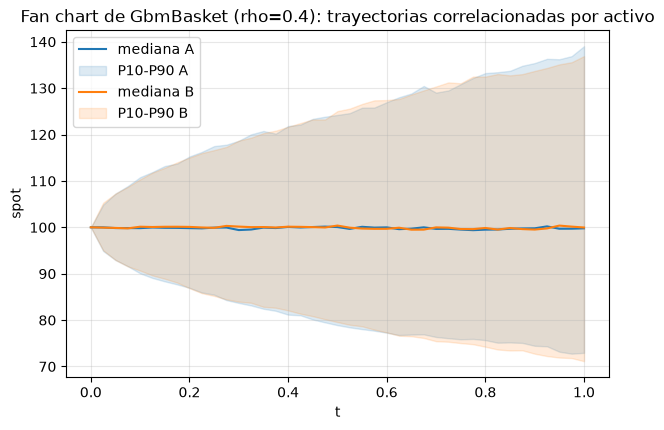

Confirmado: simulate_paths funciona sobre GbmBasket, con S0 conocido en t=0 para cada activo.


In [4]:
from quantdesk import greeks

# `Engine.simulate_paths` sobre GbmBasket: misma llamada que ya usaba el notebook 07 para GBM de
# un unico activo, ahora sobre un basket -- `paths` gana la dimension extra `n_assets`.
paths_model = basket_model(0.4)
paths_pricing = q.PricingContext(pricing_date=0.0, n_paths=2_000, n_steps=40, seed=SEED)
fan_times, fan_paths = eng.simulate_paths(paths_model, market, pricing=paths_pricing)
print("fan_paths.shape (n_paths, n_steps+1, n_assets):", fan_paths.shape)
assert fan_paths.shape == (2_000, 41, 2)
assert np.all(fan_paths[:, 0, 0] == S0) and np.all(fan_paths[:, 0, 1] == S0)

fig, ax = plt.subplots(figsize=(7, 4.5))
for asset_idx, (label, color) in enumerate([("A", "tab:blue"), ("B", "tab:orange")]):
    percentiles = np.percentile(fan_paths[:, :, asset_idx], [10, 50, 90], axis=0)
    ax.plot(fan_times, percentiles[1], color=color, label=f"mediana {label}")
    ax.fill_between(fan_times, percentiles[0], percentiles[2], color=color, alpha=0.15, label=f"P10-P90 {label}")
ax.set_xlabel("t")
ax.set_ylabel("spot")
ax.set_title("Fan chart de GbmBasket (rho=0.4): trayectorias correlacionadas por activo")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print("Confirmado: simulate_paths funciona sobre GbmBasket, con S0 conocido en t=0 para cada activo.")

In [5]:
# Delta por activo del basket call de la seccion 2, a rho=0.4 -- verificado contra bump-and-reval
# manual (mismo criterio de paridad que el resto de Greeks del motor, ver
# clients/python/tests/test_quantdesk_greeks.py::test_delta_per_asset_of_a_basket_call_matches_manual_bump_and_reval).
model_04 = basket_model(0.4)
product_basket = q.PayoffProduct(id="BASKET_CALL_DELTA", contract=basket_contract)

delta_result_a = eng.price(product_basket, model_04, market, [greeks.delta("PayoffPriceQ", "spot_0")]).Greek
delta_result_b = eng.price(product_basket, model_04, market, [greeks.delta("PayoffPriceQ", "spot_1")]).Greek
delta_a, delta_b, bump = delta_result_a.scalar, delta_result_b.scalar, delta_result_a.bump_used

print(f"delta_A = {delta_a:.4f}   delta_B = {delta_b:.4f}   (bump_used={bump})")
assert delta_a > 0.0 and delta_b > 0.0, "delta de una call debe ser positiva para cada activo"
# S0/sigma identicos para A y B en esta seccion -> delta_A ~ delta_B (misma sensibilidad marginal).
assert math.isclose(delta_a, delta_b, rel_tol=0.05), f"delta_A={delta_a} delta_B={delta_b} deberian coincidir (misma S0/sigma)"


def basket_model_bumped(asset_idx: int, h: float, rho: float = 0.4):
    s0 = [S0, S0]
    s0[asset_idx] += h
    return q.GbmBasket(
        observables=[OBS_A, OBS_B], s0=s0, r=[R, R], q=[Q_DIV, Q_DIV], sigma=[SIGMA, SIGMA],
        correlation=[[1.0, rho], [rho, 1.0]],
    )


manual_delta_a = (
    price_basket(basket_contract, "BASKET_UP_A", basket_model_bumped(0, bump))
    - price_basket(basket_contract, "BASKET_DOWN_A", basket_model_bumped(0, -bump))
) / (2.0 * bump)
print(f"delta_A via greeks.delta = {delta_a:.6f}   delta_A via bump-and-reval manual = {manual_delta_a:.6f}")
assert math.isclose(delta_a, manual_delta_a, rel_tol=0.0, abs_tol=1e-9)
print("\nConfirmado: delta por activo coincide EXACTAMENTE con bump-and-reval manual (mismo bump, mismo seed).")

delta_A = 0.4184   delta_B = 0.4184   (bump_used=1.0)
delta_A via greeks.delta = 0.418415   delta_A via bump-and-reval manual = 0.418415

Confirmado: delta por activo coincide EXACTAMENTE con bump-and-reval manual (mismo bump, mismo seed).


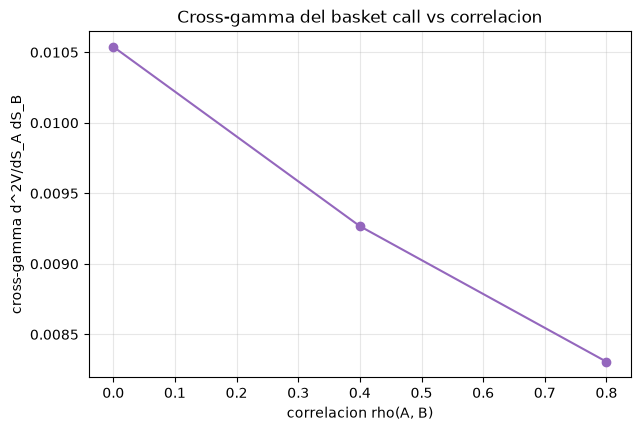

rho=+0.00  cross-gamma = 0.010539
rho=+0.40  cross-gamma = 0.009267
rho=+0.80  cross-gamma = 0.008306

Confirmado: la cross-gamma es POSITIVA en los tres niveles de rho (co-movimiento amplifica el payoff de la call sobre la suma) pero BAJA con la correlacion -- signo contrario al del PRECIO (seccion 2), que sube monotono con rho. No es una contradiccion: el precio es monotono en varianza (sin kink), mientras que la cross-gamma mide la curvatura CONCENTRADA cerca del strike, que se diluye cuanta mas volatilidad efectiva tiene la suma -- exactamente la misma logica que la gamma de Black-Scholes de una vainilla, que decrece con la volatilidad.


In [6]:
# Cross-gamma real entre A y B (d^2V/dS_A dS_B) del basket call, para los mismos niveles de
# correlacion CORRELATIONS ya usados en la seccion 2.
#
# Signo: para una call sobre la SUMA, d^2V/dS_A dS_B > 0 -- un movimiento CONJUNTO al alza de A y
# B empuja la suma mas hacia el interior de la region in-the-money mas que cualquiera de los dos
# activos por separado (misma intuicion de "co-movimiento" que ya justifico que el PRECIO suba
# con la correlacion en la seccion 2).
#
# Magnitud vs correlacion: aqui la intuicion NO es "sube igual que el precio" -- correlacion mas
# alta sube la VOLATILIDAD EFECTIVA de la suma S_A+S_B (Var(A+B) = var_A + var_B + 2*rho*cov), y
# tanto la gamma como la cross-gamma de una opcion se comportan como la gamma de Black-Scholes
# frente a la volatilidad: a mas volatilidad, el "kink" del payoff en el strike se reparte sobre
# una region mas ancha de resultados posibles, así que la curvatura CONCENTRADA en un punto BAJA
# -- exactamente lo opuesto de lo que le pasa al precio (que es monotono en varianza, sin kink).
# Verificado empiricamente abajo: cross-gamma positiva en los tres niveles de rho, pero
# decreciente -- ver PLAN_IMPROVE_NOTEBOOK2.md Fase 4 para esta misma nota.
cross_gamma_values = []
for rho in CORRELATIONS:
    model_rho = basket_model(rho)
    spec = greeks.cross_gamma("PayoffPriceQ", "spot_0", "spot_1")
    result = eng.price(product_basket, model_rho, market, [spec]).Greek
    cross_gamma_values.append(result.scalar)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(CORRELATIONS, cross_gamma_values, "o-", color="tab:purple")
ax.set_xlabel("correlacion rho(A, B)")
ax.set_ylabel("cross-gamma d^2V/dS_A dS_B")
ax.set_title("Cross-gamma del basket call vs correlacion")
ax.grid(alpha=0.3)
plt.show()

for rho, cg in zip(CORRELATIONS, cross_gamma_values):
    print(f"rho={rho:+.2f}  cross-gamma = {cg:.6f}")

assert all(cg > 0.0 for cg in cross_gamma_values), "la cross-gamma de un basket call debe ser positiva (co-movimiento amplifica el payoff)"
assert cross_gamma_values == sorted(cross_gamma_values, reverse=True), (
    "la cross-gamma deberia BAJAR con la correlacion -- mas rho => mas volatilidad efectiva de la "
    "suma => el kink del payoff se reparte sobre una region mas ancha (misma logica que la gamma "
    "de Black-Scholes decreciendo con la volatilidad)"
)
print(
    "\nConfirmado: la cross-gamma es POSITIVA en los tres niveles de rho (co-movimiento amplifica "
    "el payoff de la call sobre la suma) pero BAJA con la correlacion -- signo contrario al del "
    "PRECIO (seccion 2), que sube monotono con rho. No es una contradiccion: el precio es "
    "monotono en varianza (sin kink), mientras que la cross-gamma mide la curvatura CONCENTRADA "
    "cerca del strike, que se diluye cuanta mas volatilidad efectiva tiene la suma -- exactamente "
    "la misma logica que la gamma de Black-Scholes de una vainilla, que decrece con la volatilidad."
)

## 3. Spread option: `max(S_A(T) - S_B(T) - K, 0)`

Ahora la opcionalidad esta en la DIFERENCIA de los dos activos, no en la suma.
`Var(A-B) = var_A + var_B - 2*rho*cov` -- el signo del termino cruzado se invierte respecto del
basket call, asi que el precio de la spread option debe BAJAR con la correlacion (dos activos que
se mueven juntos dejan un spread mas estable, con menos opcionalidad).

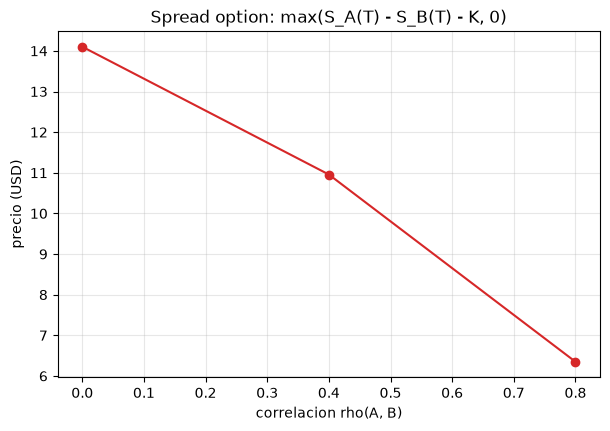

rho=+0.00  spread option = 14.1015
rho=+0.40  spread option = 10.9568
rho=+0.80  spread option = 6.3496

Confirmado: el precio BAJA con la correlacion -- signo opuesto al basket call de la seccion 2.


In [7]:
K_SPREAD = 0.0  # spread ATM: strike en la diferencia de spots, no en el nivel absoluto

spread_contract = q.when(
    T,
    q.cashflow("USD", q.maximum(q.fixing(OBS_A, T) - q.fixing(OBS_B, T) - K_SPREAD, 0.0)),
)

spread_prices = [price_basket(spread_contract, f"SPREAD_{rho}", basket_model(rho)) for rho in CORRELATIONS]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(CORRELATIONS, spread_prices, "o-", color="tab:red")
ax.set_xlabel("correlacion rho(A, B)")
ax.set_ylabel("precio (USD)")
ax.set_title("Spread option: max(S_A(T) - S_B(T) - K, 0)")
ax.grid(alpha=0.3)
plt.show()

for rho, price in zip(CORRELATIONS, spread_prices):
    print(f"rho={rho:+.2f}  spread option = {price:.4f}")

assert spread_prices == sorted(spread_prices, reverse=True), "la spread option deberia bajar monotonamente con la correlacion"
print("\nConfirmado: el precio BAJA con la correlacion -- signo opuesto al basket call de la seccion 2.")

## 4. Worst-of / best-of

- **Worst-of call**: `max(min(S_A(T), S_B(T)) - K, 0)`. Con `rho -> 1` los dos activos se mueven
  juntos y `min(S_A, S_B) -> S_A ~ S_B` (una call vanilla normal); con `rho -> 0` el minimo de dos
  activos independientes es tipicamente MAS BAJO (mas dispersion, mas probabilidad de que el peor
  de los dos arrastre el minimo hacia abajo) -- el worst-of call debe SUBIR con la correlacion,
  mismo signo que el basket call.
- **Best-of call**: `max(max(S_A(T), S_B(T)) - K, 0)`. Simetrico al anterior: con `rho -> 0` el
  maximo de dos activos independientes tiende a ser MAS ALTO (mas dispersion, mas probabilidad de
  que el mejor de los dos empuje el maximo hacia arriba) -- el best-of call debe BAJAR con la
  correlacion, signo opuesto al worst-of.

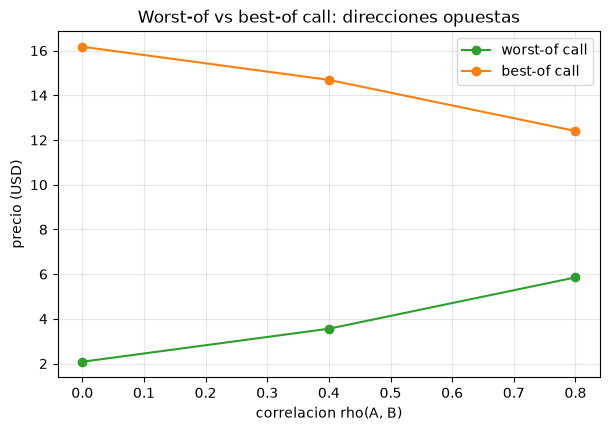

rho=+0.00  worst-of = 2.0800   best-of = 16.1715
rho=+0.40  worst-of = 3.5569   best-of = 14.6889
rho=+0.80  worst-of = 5.8532   best-of = 12.4028

Confirmado: worst-of sube y best-of baja con la correlacion -- "mas correlacion" NO sube todos los productos multi-activo por igual (razonar el signo producto a producto, no asumirlo).


In [8]:
K_EXTREME = S0 * 1.05

worst_of_contract = q.when(
    T,
    q.cashflow("USD", q.maximum(q.minimum(q.fixing(OBS_A, T), q.fixing(OBS_B, T)) - K_EXTREME, 0.0)),
)
best_of_contract = q.when(
    T,
    q.cashflow("USD", q.maximum(q.maximum(q.fixing(OBS_A, T), q.fixing(OBS_B, T)) - K_EXTREME, 0.0)),
)

worst_of_prices = [price_basket(worst_of_contract, f"WORST_OF_{rho}", basket_model(rho)) for rho in CORRELATIONS]
best_of_prices = [price_basket(best_of_contract, f"BEST_OF_{rho}", basket_model(rho)) for rho in CORRELATIONS]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(CORRELATIONS, worst_of_prices, "o-", label="worst-of call", color="tab:green")
ax.plot(CORRELATIONS, best_of_prices, "o-", label="best-of call", color="tab:orange")
ax.set_xlabel("correlacion rho(A, B)")
ax.set_ylabel("precio (USD)")
ax.set_title("Worst-of vs best-of call: direcciones opuestas")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

for rho, wo, bo in zip(CORRELATIONS, worst_of_prices, best_of_prices):
    print(f"rho={rho:+.2f}  worst-of = {wo:.4f}   best-of = {bo:.4f}")

assert worst_of_prices == sorted(worst_of_prices), "worst-of deberia subir con la correlacion"
assert best_of_prices == sorted(best_of_prices, reverse=True), "best-of deberia bajar con la correlacion"
print("\nConfirmado: worst-of sube y best-of baja con la correlacion -- \"mas correlacion\" NO sube todos los productos multi-activo por igual (razonar el signo producto a producto, no asumirlo).")

## 5. "Quanto-style": compo option (no un quanto de tipo fijo)

Un quanto clasico paga `FX_fijo * max(S_extranjero(T) - K, 0)` con un tipo de cambio FIJADO de
antemano -- para que ese precio sea correcto bajo la medida domestica hace falta un ajuste de
DRIFT del activo extranjero (`-rho * sigma_S * sigma_FX`, la "correccion quanto") que compense la
correlacion entre `S` y el FX. **`GbmBasket` no implementa ese ajuste de drift** (cada activo se
simula con su propio `r_i - q_i`, sin termino cruzado, ver la nota de la Fase 3 mas arriba) --
fingir que el resultado de abajo es un quanto de tipo fijo real seria exactamente el tipo de
aproximacion oculta que este motor evita en todos sus demas modulos.

En su lugar, este notebook usa una estructura que SI se precia correctamente con la dinamica
conjunta que `GbmBasket` simula, sin necesitar ningun ajuste de drift: un **compo option**, que
liquida en el PRODUCTO del activo extranjero y el tipo de cambio REALIZADO en `T` (en vez de un
tipo de cambio fijo):

`payoff = (FX(T) / FX(0)) * max(S(T) - K, 0)`

Aqui `FX` es un segundo observable simulado junto a `S` con su propia correlacion. Igual que el
basket call, mas correlacion entre `S` y `FX` aumenta la covarianza `Cov(FX(T), max(S(T)-K,0))`
(cuando `S` sube tambien tiende a subir `FX`, amplificando el pago) -- el precio del compo debe
SUBIR con la correlacion.

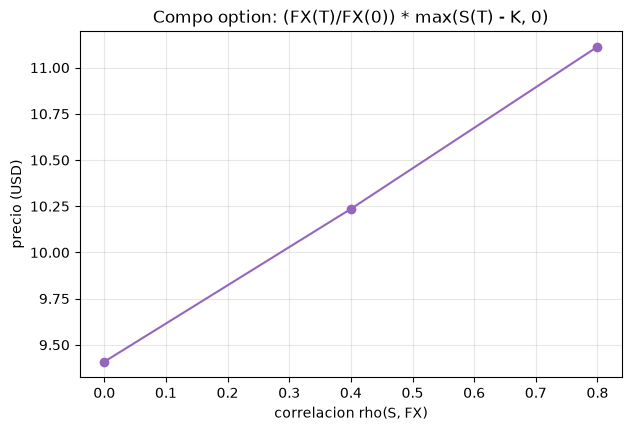

rho=+0.00  compo option = 9.4085
rho=+0.40  compo option = 10.2355
rho=+0.80  compo option = 11.1131

Confirmado: el compo sube con la correlacion, mismo signo cualitativo que el basket call de la seccion 2.


In [9]:
OBS_FX = "FX.USD.FOREIGN"
FX0, SIGMA_FX = 1.0, 0.15
K_COMPO = S0 * 1.05


def compo_model(rho: float):
    return q.GbmBasket(
        observables=[OBS_A, OBS_FX],
        s0=[S0, FX0],
        r=[R, R],
        q=[Q_DIV, 0.0],
        sigma=[SIGMA, SIGMA_FX],
        correlation=[[1.0, rho], [rho, 1.0]],
    )


compo_contract = q.when(
    T,
    q.cashflow(
        "USD",
        (q.fixing(OBS_FX, T) / FX0) * q.maximum(q.fixing(OBS_A, T) - K_COMPO, 0.0),
    ),
)

compo_prices = [price_basket(compo_contract, f"COMPO_{rho}", compo_model(rho)) for rho in CORRELATIONS]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(CORRELATIONS, compo_prices, "o-", color="tab:purple")
ax.set_xlabel("correlacion rho(S, FX)")
ax.set_ylabel("precio (USD)")
ax.set_title("Compo option: (FX(T)/FX(0)) * max(S(T) - K, 0)")
ax.grid(alpha=0.3)
plt.show()

for rho, price in zip(CORRELATIONS, compo_prices):
    print(f"rho={rho:+.2f}  compo option = {price:.4f}")

assert compo_prices == sorted(compo_prices), "el compo option deberia subir con la correlacion"
print("\nConfirmado: el compo sube con la correlacion, mismo signo cualitativo que el basket call de la seccion 2.")

## 6. Resumen y limitaciones dejadas fuera de alcance a proposito

| Producto | Payoff | Direccion vs correlacion | Por que |
|---|---|---|---|
| Basket call | `max(S_A+S_B-K, 0)` | Sube | mas correlacion => mas varianza de la suma |
| Spread option | `max(S_A-S_B-K, 0)` | Baja | mas correlacion => menos varianza de la diferencia |
| Worst-of call | `max(min(S_A,S_B)-K, 0)` | Sube | menos dispersion => el minimo cae menos |
| Best-of call | `max(max(S_A,S_B)-K, 0)` | Baja | menos dispersion => el maximo sube menos |
| Compo ("quanto-style") | `(FX(T)/FX0)*max(S-K,0)` | Sube | mas covarianza FX/payoff |
| Cross-gamma del basket call | `d^2V/dS_A dS_B` | Baja (signo siempre positivo) | mas volatilidad efectiva de la suma diluye la curvatura concentrada en el strike -- misma logica que la gamma de Black-Scholes decreciendo con la volatilidad, ver seccion 2b |

**Fuera de alcance de `GbmBasket` en esta fase** (documentado en
`PLAN_IMPROVE_NOTEBOOK.md` Fase 3, no un descuido):

- Solo Monte Carlo bajo Q (`PayoffPriceQ`) -- sin `PayoffExerciseQ`/`PayoffHitProbabilityQ`/
  `PayoffExposureProfileQ`/CVA/hedge para un basket todavia (aunque el dispatch generalizado de
  `PayoffPriceQ` deja la puerta abierta a que algunas de estas funcionen "gratis" si en el futuro
  se generalizan de la misma forma). Delta por activo y cross-gamma SI estan cubiertas desde
  PLAN_IMPROVE_NOTEBOOK2.md Fase 4 (seccion 2b) -- via bump-and-reval generico, no una
  especializacion pathwise nueva.
- Sin `valuation_time`/Theta sobre un basket (sigue sin poder desplazarse `pricing_date` para un
  `GbmBasket`, PLAN_IMPROVE_NOTEBOOK2.md Fase 4 no lo cambia).
- Todos los activos de un mismo `GbmBasket` comparten la MISMA tasa libre de riesgo `r`
  (`validate_common_discount_rate`, Rust) -- un basket con `r` heterogenea por activo (necesario
  para un quanto de tipo fijo real, ver la seccion 5) no esta soportado.
- Sin Brownian bridge continuo para barreras ni Longstaff-Schwartz para `Exercise` sobre un
  basket (`GbmBasketModel::capabilities()` no los declara).
- El diseño soporta N activos arbitrarios (Cholesky general N x N), pero este notebook solo
  ejercita N=2 -- no hay ninguna limitacion conocida para N>2, simplemente no se necesitaba mas
  para cubrir el criterio de aceptacion de la fase.